In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.3 MB/s eta 0:00:00


In [2]:
!unzip "/content/brain_stock.v1i.yolov11.zip"

Archive:  /content/brain_stock.v1i.yolov11.zip
  inflating: README.dataset.txt      
  inflating: README.roboflow.txt     
  inflating: data.yaml               
   creating: test/
   creating: test/images/
 extracting: test/images/glioma2204_jpg.rf.adbe4e6c39cc5853abc0dda145166293.jpg  
 extracting: test/images/glioma2216_jpg.rf.5298314ce14c436e051db3e45dcf7581.jpg  
 extracting: test/images/glioma2220_jpg.rf.9c8a28947210ca3854290d38d49afc99.jpg  
 extracting: test/images/glioma2226_jpg.rf.b4e3c01cfb76a51fa1b810909a0c8734.jpg  
 extracting: test/images/glioma2229_jpg.rf.e167b86ee2eb8d27b93d6db9972c235e.jpg  
 extracting: test/images/glioma2230_jpg.rf.0a730b94bfcb81155a52b7523b6d1fbf.jpg  
 extracting: test/images/glioma2239_jpg.rf.ccfd9398968fc8536347dce93974f081.jpg  
 extracting: test/images/glioma2241_jpg.rf.9513eed6b8b47a6f0d92c7b96c83a96d.jpg  
 extracting: test/images/glioma2247_jpg.rf.7188a4e07db15c01da111e6b9154b736.jpg  
 extracting: test/images/glioma2255_jpg.rf.d494aa873ef77

In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
model = YOLO("yolov8n.pt")

In [5]:
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [6]:
!mkdir -p val/images val/labels
!cp train/images/* val/images/
!cp train/labels/* val/labels/


In [9]:
results = model.train(data="data.yaml", epochs=50, imgsz=640)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

Interpretation

* Precision 97.7% → Predictions are very accurate
* Recall 99.4% → Almost all tumors detected
* mAP50 99.3% → Excellent detection performance
* mAP50-95 78.1% → Good but can still improve slightly

### Model Performance by Class

| Class      | Precision | Recall | mAP50 | mAP50-95 |
|------      |-----------|--------|-------|----------|
| Glioma     | 0.966     | 0.977  | 0.989 | 0.717 |
| Meningioma | 0.980     | 1.000  | 0.994 | 0.736 |
| No Tumor   | 0.992     | 1.000  | 0.995 | 0.978 |
| Pituitary  | 0.971     | 1.000  | 0.995 | 0.693 |

In [10]:
model = YOLO("/content/runs/detect/train3/weights/best.pt")


image 1/1 /content/meningioma414.png: 640x640 1 Meningioma, 7.2ms
Speed: 2.5ms preprocess, 7.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


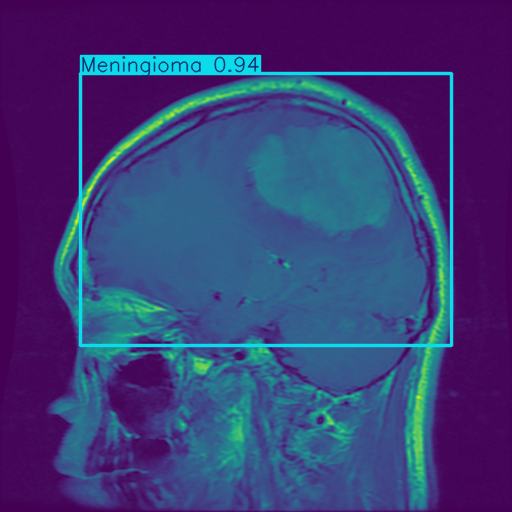

In [11]:
results = model("/content/meningioma414.png", conf=0.5)
results[0].show()


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/Brain_Tumor/best.pt")


image 1/1 /content/meningioma414.png: 640x640 1 Meningioma, 7.3ms
Speed: 2.6ms preprocess, 7.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


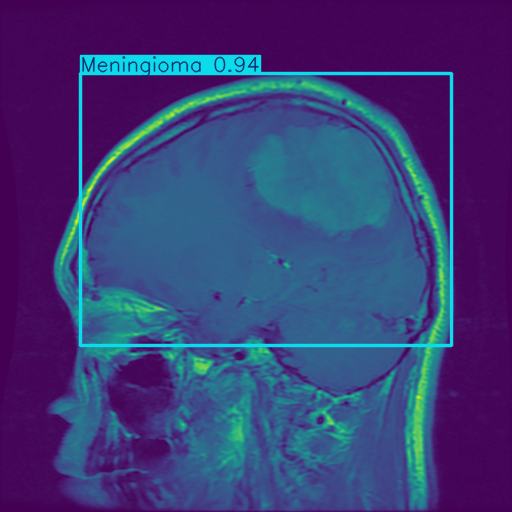

In [15]:
results = model("/content/meningioma414.png", conf=0.5)
results[0].show()



image 1/1 /content/pituitary882.png: 640x640 1 Pituitary, 7.3ms
Speed: 2.6ms preprocess, 7.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


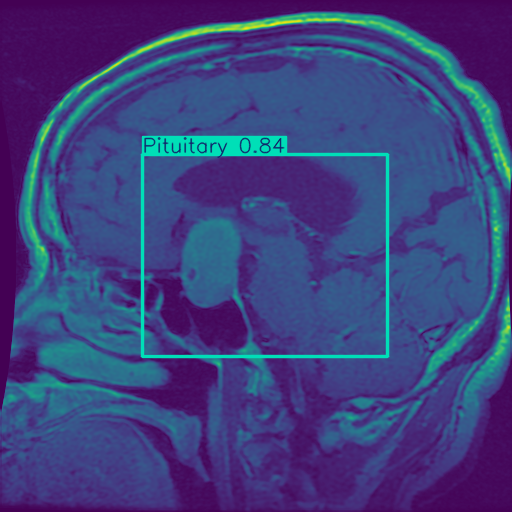

In [17]:
results = model("/content/pituitary882.png", conf=0.5)
results[0].show()



image 1/1 /content/no_tumor2.JPG: 640x576 1 No_Tumor, 47.3ms
Speed: 3.2ms preprocess, 47.3ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 576)


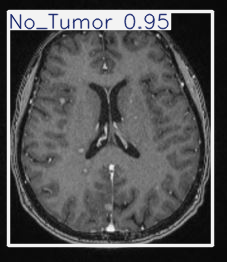

In [19]:
results = model("/content/no_tumor2.JPG", conf=0.5)
results[0].show()